In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import os

# Load the data
data = pd.read_csv("Course_Completion_Prediction.csv")
print("First five data")
print(data.head().to_string())
print("\nData Columns")
print(data.columns.to_list())
print("\nData shape")
print(data.shape)

# check for missing values
print("\nChecking missing values")
print(data.isnull().sum())

# Feature Engineering
print("\nFeature Engineering")
# Gender mapping
gender = {"Male": 1, "Female": 0}
data["Gender"] = data["Gender"].map(gender)

#Education level to number
education = {"HighSchool": 1,
           "Diploma": 2,
           "Bachelor": 3,
           "Master": 4,
           "PhD" : 5 }
data["Education_Level"] = data["Education_Level"].map(education)

#Employment level to number
employment = {"Unemployed": 1,
           "Student ": 2,
           "Employed ": 3,
           "Self-Employed": 4,
           }
data["Employment_Status"] = data["Employment_Status"].map(employment)
#Device type to number
device = {"Mobile": 1,
           "Laptop": 2,
           "Tablet ": 3
           }
data["Device_Type"] = data["Device_Type"].map(device)
print(data["Device_Type"].value_counts())

# Choose simple features first
simple_features = [
    'Login_Frequency',           
    'Time_Spent_Hours',          
    'Quiz_Score_Avg',            
    'Assignments_Submitted',         
    'Project_Grade',             
    'Progress_Percentage',       
    'Video_Completion_Rate',     
    'Age',                       
    'Discussion_Participation',  
    'Peer_Interaction_Score',     
    'App_Usage_Percentage',
    "Course_Duration_Days",
    "Instructor_Rating",
]

# Target
data['Completed'] = (data['Completed'] == 'Completed').astype(int)

# Select only these columns
X = data[simple_features]
y = data['Completed']


print(f"\nX shape:{X.shape}")
print(f"\ny shape:{y.shape}")

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y ,test_size=0.2, random_state=42, stratify=y
)
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill all remaining NaNs with median
imputer = SimpleImputer(strategy='median')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

# Train 
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)


# Predict
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"\nConfusion Matrix:")
print("                 Predicted")
print("                No    Yes")
print(f"Actual  No    {cm[0][0]:5d} {cm[0][1]:5d}")
print(f"        Yes   {cm[1][0]:5d} {cm[1][1]:5d}")

# Check permutation importance
result = permutation_importance(model, X_test_scaled, y_test, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
    'feature': simple_features,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

print("\nPermutation Feature Importance:")
print(importance_df)


First five data
  Student_ID             Name  Gender  Age Education_Level Employment_Status     City Device_Type Internet_Connection_Quality Course_ID                Course_Name     Category  Course_Level  Course_Duration_Days  Instructor_Rating  Login_Frequency  Average_Session_Duration_Min  Video_Completion_Rate  Discussion_Participation  Time_Spent_Hours  Days_Since_Last_Login  Notifications_Checked  Peer_Interaction_Score  Assignments_Submitted  Assignments_Missed  Quiz_Attempts  Quiz_Score_Avg  Project_Grade  Progress_Percentage  Rewatch_Count Enrollment_Date Payment_Mode Fee_Paid Discount_Used  Payment_Amount  App_Usage_Percentage  Reminder_Emails_Clicked  Support_Tickets_Raised  Satisfaction_Rating      Completed
0  STU100000     Vihaan Patel    Male   19         Diploma           Student   Indore      Laptop                      Medium      C102  Data Analysis with Python  Programming  Intermediate                    60                4.7                3                      

In [83]:
# Try with Random Forest
from sklearn.ensemble import RandomForestClassifier
modelRF = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelRF.fit(X_train_scaled, y_train)

# Predict
y_pred = modelRF.predict(X_test_scaled)
y_proba = modelRF.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"\nConfusion Matrix:")
print("                 Predicted")
print("                No    Yes")
print(f"Actual  No    {cm[0][0]:5d} {cm[0][1]:5d}")
print(f"        Yes   {cm[1][0]:5d} {cm[1][1]:5d}")
print(data['Completed'].value_counts(normalize=True))

# Get feature importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': modelRF.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

Accuracy:  0.5999 (60.0%)
Precision: 0.5939
Recall:    0.5818
F1-Score:  0.5878

Confusion Matrix:
                 Predicted
                No    Yes
Actual  No     6293  3901
        Yes    4101  5705
Completed
0    0.5097
1    0.4903
Name: proportion, dtype: float64
                     feature  importance
5        Progress_Percentage    0.435756
6      Video_Completion_Rate    0.270358
3      Assignments_Submitted    0.124534
1           Time_Spent_Hours    0.088057
2             Quiz_Score_Avg    0.046452
4              Project_Grade    0.009528
0            Login_Frequency    0.006081
9     Peer_Interaction_Score    0.005666
10      App_Usage_Percentage    0.005244
7                        Age    0.003305
8   Discussion_Participation    0.002768
11      Course_Duration_Days    0.001309
12         Instructor_Rating    0.000942


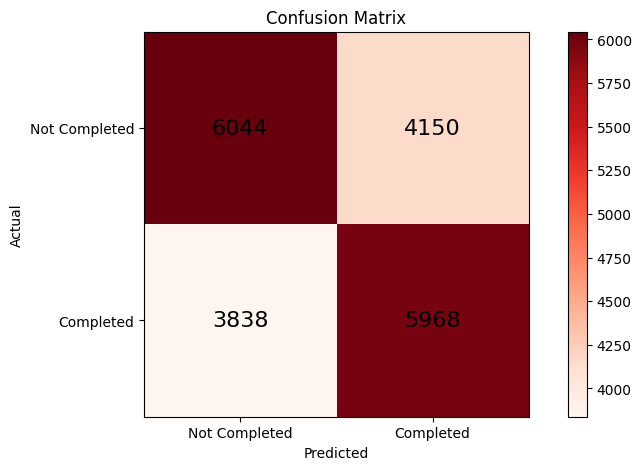

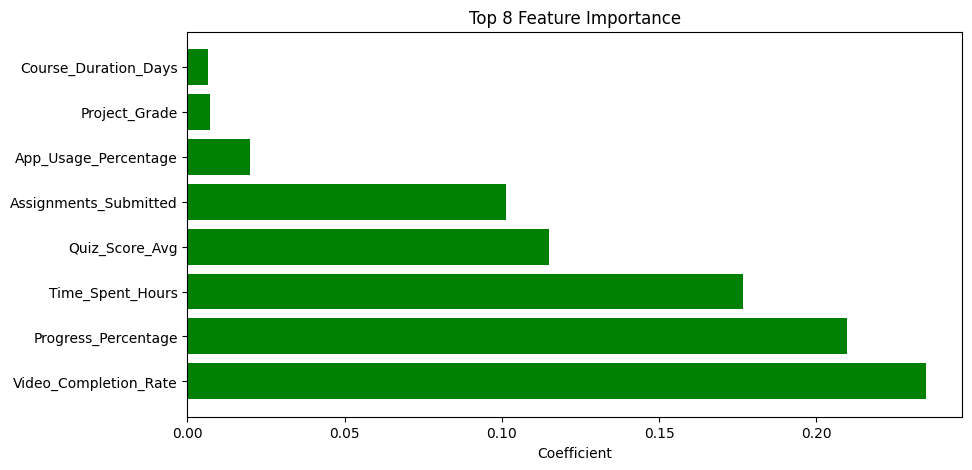

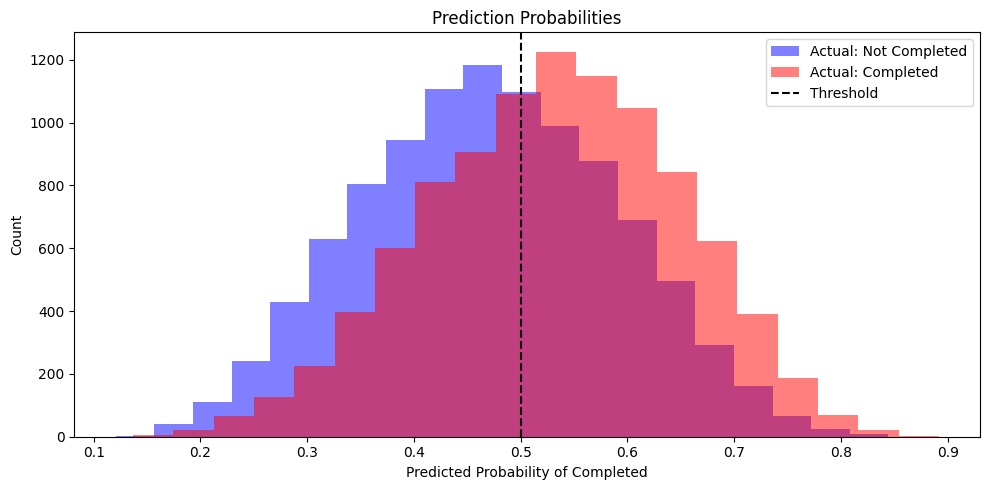

In [87]:
# ============================================
#  PLOTTING
# ============================================

os.makedirs('Cost_Completion_prediction_figs', exist_ok=True)



# Plot 1: Confusion Matrix
# plot_confusion_matrix(y_test, y_pred, class_names=['Not Completed', 'Completed'])
plt.figure(figsize=(10, 5))
plt.imshow(cm, interpolation='nearest', cmap='Reds')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Not Completed', 'Completed'])
plt.yticks([0, 1], ['Not Completed', 'Completed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16)

# Plot 2: Feature Importance
# plot_feature_importance(feature_cols, model.coef_[0])
plt.figure(figsize=(10, 5))
coefficients = model.coef_[0] if hasattr(model, 'coef_') else model.weights.flatten()
sorted_idx = np.argsort(np.abs(coefficients))[::-1]
sorted_names = [simple_features[i] for i in sorted_idx[:8]]  # Top 8 features
sorted_coefs = coefficients[sorted_idx[:8]]
colors = ['red' if c < 0 else 'green' for c in sorted_coefs]
plt.barh(sorted_names, sorted_coefs, color=colors)
plt.xlabel('Coefficient')
plt.title('Top 8 Feature Importance')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# # Plot 3: Probability Distribution
# plot_probability_distribution(y_test, y_proba, class_names=['Not Completed', 'Completed'])
plt.figure(figsize=(10, 5))
plt.hist(y_proba[y_test == 0], bins=20, alpha=0.5, label='Actual: Not Completed', color='blue')
plt.hist(y_proba[y_test == 1], bins=20, alpha=0.5, label='Actual: Completed', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
plt.xlabel(f'Predicted Probability of {['Not Completed', 'Completed'][1]}')
plt.ylabel('Count')
plt.title('Prediction Probabilities')
plt.legend()

plt.tight_layout()
plt.savefig('Cost_Completion_prediction_figs.png')
plt.show()